# 01 — Participant Screening

This notebook applies exclusion criteria to the raw behavioural data and generates `data/reject.csv`, which is required by all subsequent notebooks.

**Exclusion criteria:**
1. Go-to-Win accuracy in the controllable condition ≤ 55% (failure to acquire basic action–outcome contingencies)
2. Invariant responding (overall Go rate < 10% or > 90%)
3. Did not complete both sessions

**Output:** `data/reject.csv` — one row per participant with exclusion flags and final `reject` column

## 1 — Setup

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas import read_csv, DataFrame

ANALYSIS_DIR = os.getcwd()
DATA_DIR     = os.path.join(ANALYSIS_DIR, 'data')
FIG_DIR      = os.path.join(ANALYSIS_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

labelcolor = '#505050'
tickcolor  = '#606060'
axiscolor  = '#d3d3d3'

sns.set_theme(style='ticks', context='notebook', font_scale=1.2)
print('Setup complete.')

Setup complete.


## 2 — Load Data

In [2]:
data_all = read_csv(os.path.join(DATA_DIR, 'pgng.csv'))
data     = data_all.query('session == 1')   # Session 1 for behavioural screening

subjects = data['subject'].unique()
reject   = DataFrame({'subject': subjects, 'reject': 0})

print(f'Total participants (session 1): {len(subjects)}')
print(f'Total sessions in data: {data_all["session"].unique()}')

Total participants (session 1): 25
Total sessions in data: [1 2]


## 3 — Screening Plots

### 3.1 Choice Variability

In [3]:
# Compute overall Go rate per subject
overall_go = data.groupby('subject')['choice'].mean().reset_index()
overall_go = overall_go.rename(columns={'choice': 'overall_go'})
reject     = reject.merge(overall_go, on='subject', how='left')

print('Overall Go rate summary:')
print(overall_go['overall_go'].describe().round(3))
print(f'\nParticipants with Go rate < 10%: {(overall_go["overall_go"] < 0.1).sum()}')
print(f'Participants with Go rate > 90%: {(overall_go["overall_go"] > 0.9).sum()}')

Overall Go rate summary:
count    25.000
mean      0.624
std       0.119
min       0.306
25%       0.544
50%       0.658
75%       0.686
max       0.819
Name: overall_go, dtype: float64

Participants with Go rate < 10%: 0
Participants with Go rate > 90%: 0


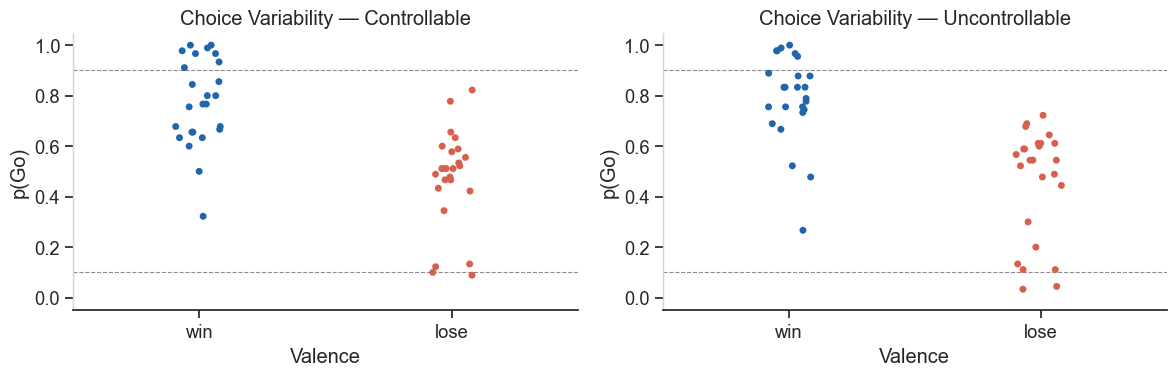

Dashed lines indicate exclusion thresholds (Go rate < 10% or > 90%)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('white')

for ax, cond in zip(axes, ['controllable', 'uncontrollable']):
    gb = (data[data['controllability'] == cond]
          .groupby(['subject', 'valence'])['choice'].mean().reset_index())
    sns.stripplot(x='valence', y='choice', order=['win', 'lose'],
                  hue='valence', hue_order=['win', 'lose'],
                  palette={'win': '#2166ac', 'lose': '#d6604d'},
                  data=gb, legend=False, ax=ax)
    ax.axhline(0.1, linestyle='--', lw=0.8, color='k', alpha=0.5)
    ax.axhline(0.9, linestyle='--', lw=0.8, color='k', alpha=0.5)
    ax.set(xlabel='Valence', ylim=(-0.05, 1.05), ylabel='p(Go)',
           title=f'Choice Variability — {cond.capitalize()}')
    ax.spines['left'].set(linewidth=1, color=axiscolor)
    sns.despine(ax=ax, left=False, right=True, top=True, bottom=False)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'screening_variability.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Dashed lines indicate exclusion thresholds (Go rate < 10% or > 90%)')

### 3.2 Accuracy by Trial Type

In [5]:
# Compute GW accuracy in controllable condition
gw_ctrl = (data[(data['robot_type'] == 'gw') &
                (data['controllability'] == 'controllable')]
           .groupby('subject')['accuracy'].mean().reset_index()
           .rename(columns={'accuracy': 'gw_controllable'}))

print('GW accuracy in controllable condition:')
print(gw_ctrl['gw_controllable'].describe().round(3))
print(f'\nParticipants failing criterion (≤ 55%): {(gw_ctrl["gw_controllable"] <= 0.55).sum()}')

GW accuracy in controllable condition:
count    25.000
mean      0.908
std       0.138
min       0.311
25%       0.889
50%       0.933
75%       0.978
max       1.000
Name: gw_controllable, dtype: float64

Participants failing criterion (≤ 55%): 1


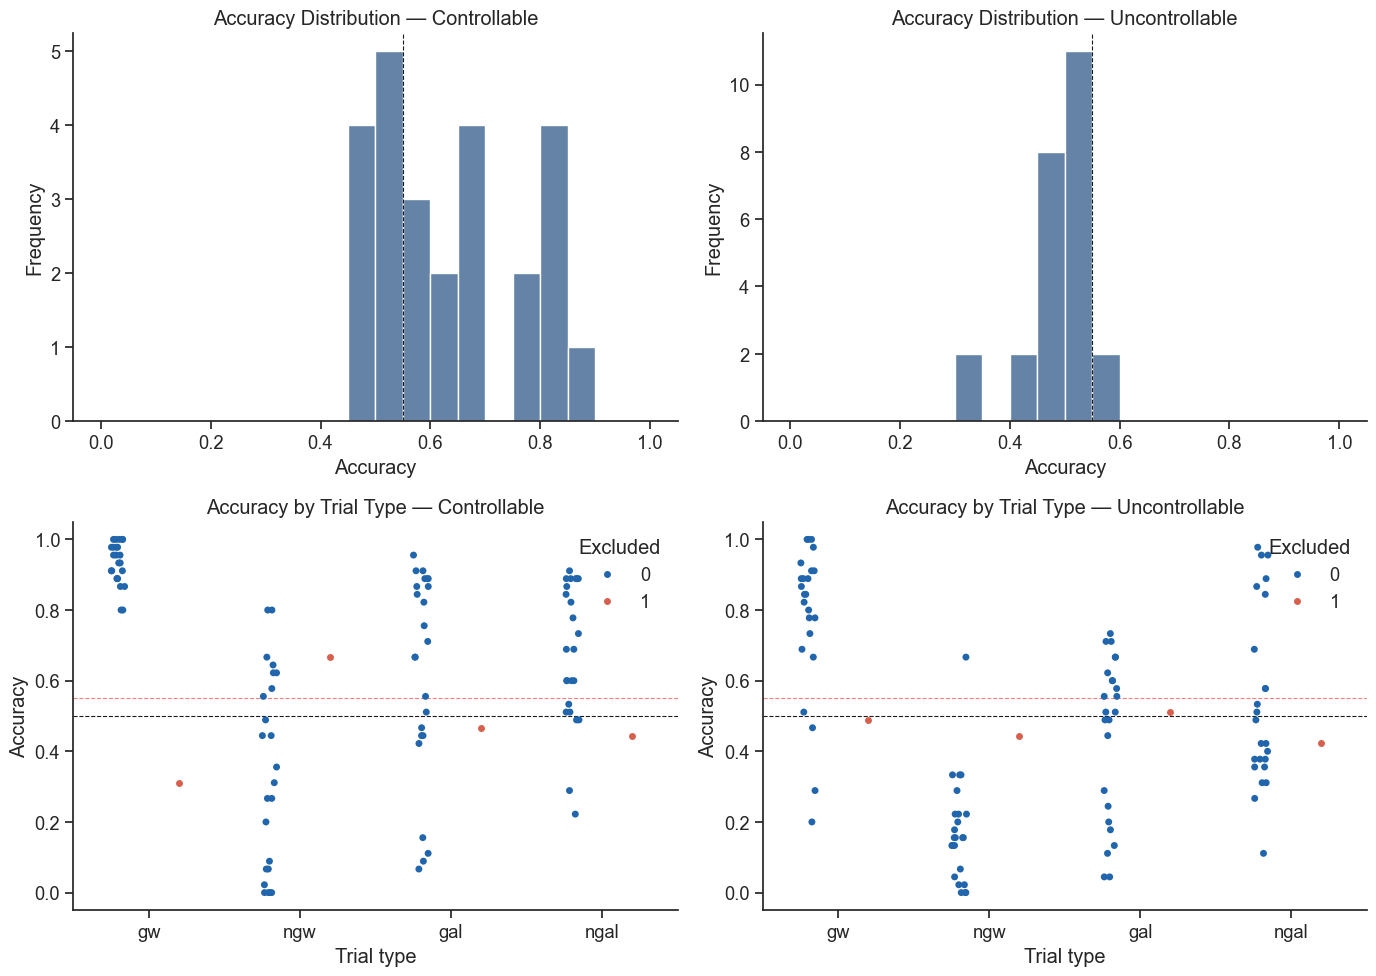

In [6]:
gb = data.groupby(['subject', 'robot_type', 'controllability'])['accuracy'].mean().reset_index()
gb = gb.merge(gw_ctrl, on='subject', how='left')
gb['fail'] = gb['subject'].isin(
    gw_ctrl[gw_ctrl['gw_controllable'] <= 0.55]['subject']
).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('white')

for col, cond in enumerate(['controllable', 'uncontrollable']):
    sub = gb[gb['controllability'] == cond]

    # Row 0: accuracy distribution
    sns.histplot(x='accuracy',
                 data=sub.groupby('subject')['accuracy'].mean().reset_index(),
                 bins=np.linspace(0, 1, 21), ax=axes[0, col],
                 color='#234f81', alpha=0.7)
    axes[0, col].axvline(0.55, linestyle='--', lw=0.8, color='k')
    axes[0, col].set(xlabel='Accuracy', ylabel='Frequency',
                     title=f'Accuracy Distribution — {cond.capitalize()}')
    sns.despine(ax=axes[0, col])

    # Row 1: accuracy by trial type
    sns.stripplot(x='robot_type', y='accuracy', hue='fail', data=sub,
                  order=['gw', 'ngw', 'gal', 'ngal'],
                  palette={0: '#2166ac', 1: '#d6604d'},
                  dodge=True, ax=axes[1, col])
    axes[1, col].axhline(0.5, linestyle='--', lw=0.8, color='k')
    axes[1, col].axhline(0.55, linestyle='--', lw=0.8, color='red', alpha=0.5)
    axes[1, col].set(xlabel='Trial type', ylabel='Accuracy',
                     title=f'Accuracy by Trial Type — {cond.capitalize()}')
    axes[1, col].legend(loc='upper right', frameon=False, title='Excluded')
    sns.despine(ax=axes[1, col])

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'screening_accuracy.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4 — Apply Exclusion Criteria

In [7]:
thresh = reject.copy()

# Criterion 1: GW accuracy in controllable condition <= 55%
thresh = thresh.merge(gw_ctrl, on='subject', how='left')
thresh['fail_gw'] = (thresh['gw_controllable'] <= 0.55).astype(int)

# Criterion 2: Invariant responding (overall Go rate < 10% or > 90%)
thresh['fail_invariant'] = (
    (thresh['overall_go'] > 0.9) |
    (thresh['overall_go'] < 0.1)
).astype(int)

# Criterion 3: Did not complete both sessions
completed_both = (data_all.groupby('subject')['session']
                           .nunique()
                           .reset_index(name='n_sessions'))
thresh = thresh.merge(completed_both, on='subject', how='left')
thresh['fail_sessions'] = (thresh['n_sessions'] < 2).astype(int)

# Aggregate
thresh['task']   = ((thresh['fail_gw'] == 1) | (thresh['fail_invariant'] == 1)).astype(int)
thresh['reject'] = ((thresh['task'] == 1) | (thresh['fail_sessions'] == 1)).astype(int)

# Save
thresh.to_csv(os.path.join(DATA_DIR, 'reject.csv'), index=False)
print(f'Rejection rate: {(thresh["reject"] > 0).mean():.3f}')
print(f'Final sample: {(thresh["reject"] == 0).sum()} / {thresh["reject"].size}')

Rejection rate: 0.040
Final sample: 24 / 25


## 5 — Exclusion Summary

In [10]:
print('Failure rates per criterion:')
print(thresh[['fail_gw', 'fail_invariant', 'fail_sessions']].mean().round(3))

print('\nExcluded participants:')
excluded = thresh[thresh['reject'] == 1][
    ['gw_controllable', 'overall_go',
     'fail_gw', 'fail_invariant', 'fail_sessions']
]
if len(excluded) == 0:
    print('  None')
else:
    print(excluded.to_string(index=False))

print('\nAll participants summary:')
print(thresh[[ 'gw_controllable', 'overall_go',
              'fail_gw', 'fail_invariant', 'reject']].to_string(index=False))

Failure rates per criterion:
fail_gw           0.04
fail_invariant    0.00
fail_sessions     0.00
dtype: float64

Excluded participants:
 gw_controllable  overall_go  fail_gw  fail_invariant  fail_sessions
        0.311111       0.475        1               0              0

All participants summary:
 gw_controllable  overall_go  fail_gw  fail_invariant  reject
        0.933333    0.519444        0               0       0
        0.977778    0.686111        0               0       0
        0.911111    0.444444        0               0       0
        1.000000    0.544444        0               0       0
        1.000000    0.786111        0               0       0
        0.911111    0.666667        0               0       0
        1.000000    0.625000        0               0       0
        0.933333    0.616667        0               0       0
        0.888889    0.602778        0               0       0
        0.977778    0.819444        0               0       0
        0.955556